# Plot figures for 2 new papers about the DM-z relation

Plot FRB DM-z relation for two recently paper:

[Surajit](https://ui.adsabs.harvard.edu/abs/2024arXiv241001974K/abstract)

[Kritti](https://ui.adsabs.harvard.edu/abs/2024arXiv240916964S/abstract)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import astropy.units as astu
import astropy.constants as const
from astropy.cosmology import FlatLambdaCDM
from astropy.cosmology import z_at_value
from astropy.cosmology import Planck18

In [4]:
df1 = pd.read_csv('FRB_Surajit.csv')
df1['DM_ext']=df1['DM_obs (pc cm^-3)']-df1['DM_MW (pc cm^-3)']
df1.head()

,FRB,DM_obs (pc cm^-3),E_DM_obs,DM_MW (pc cm^-3),z,DM_ext
0,FRB 20121102A,557.00,2.00,188.0,0.19273,369.00
1,FRB 20171020A,114.10,0.20,38.0,0.00860,76.10
2,FRB 20180301A,522.00,0.20,152.0,0.33040,370.00
3,FRB 20180916B,349.30,0.20,200.0,0.03370,149.30
4,FRB 20180924B,361.42,0.06,40.5,0.32140,320.92


In [5]:
fit1=np.polyfit(df1['z'], df1['DM_ext'],1)
slope1, intercept1 = fit1
print(slope1, intercept1)

991.3071455696436 146.4094670431233


In [6]:
df2 = pd.read_excel('FRB_Kritti.xlsx')
df2.head()

,FRB,RA,Decl,z,E_z,DM_ext
0,20220319D,02:08:42.70,+71:02:06.94,0.0112,0.0001,-22
1,20231120A,09:35:56.15,+73:17:04.80,0.0368,0.0001,395
2,20220207C,20:40:47.89,+72:52:56.38,0.0433,0.0001,182
3,20220509G,18:50:40.80,+70:14:37.80,0.0894,0.0001,214
4,20230124A,15:27:39.9,+70:58:05.20,0.0939,0.0002,551


In [7]:
fit2=np.polyfit(df2.loc[:,'z'], df2.loc[:,'DM_ext'],1)
slope2, intercept2 = fit2
print(slope2, intercept2)

882.5647179336669 183.94213728056727


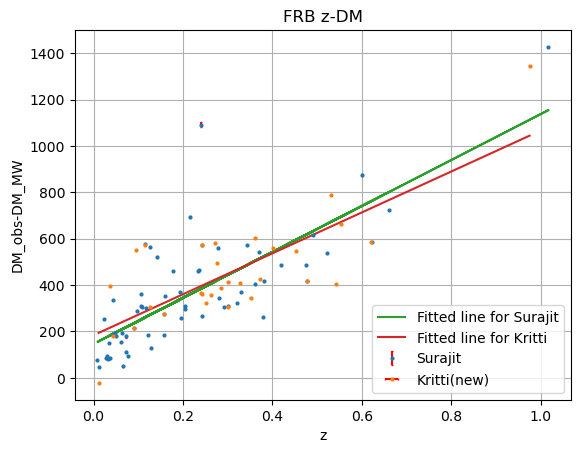

In [8]:
plt.errorbar(df1['z'], df1['DM_ext'], yerr=df1['E_DM_obs'], fmt='o', ecolor='red', capsize=1, label='Surajit',markersize=2)
plt.errorbar(df2['z'], df2['DM_ext'], xerr=df2['E_z'], fmt='o', ecolor='red', capsize=1, label='Kritti(new)',markersize=2)
plt.plot(df1['z'],slope1*df1['z']+intercept1, label='Fitted line for Surajit')
plt.plot(df2['z'],slope2*df2['z']+intercept2, label='Fitted line for Kritti')
plt.xlabel('z')
plt.ylabel('DM_obs-DM_MW')
plt.title('FRB z-DM')
plt.legend()
plt.grid(True)
plt.show()